In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pymc as pm
import json
import pickle

In [50]:
def prepare_data_and_scalers(df):
    """
    Computes categorical index mappings and feature scalers 
    for both Model 1 and Model 2 on the full dataset.
    """
    df = df.copy()
    
    # Common Categorical Mappings
    sets = df['set'].astype('category')
    rarities = df['rarity'].astype('category')
    
    set_mapping = dict(enumerate(sets.cat.categories))
    rarity_mapping = dict(enumerate(rarities.cat.categories))
    
    df['set_idx'] = sets.cat.codes.values
    df['rarity_idx'] = rarities.cat.codes.values

    # Feature Engineering
    df['log_price'] = np.log(df['current_price'])
    df['target_log_return'] = df.groupby('card')['log_price'].diff()
    df.dropna(subset=['target_log_return'], inplace=True)
    df['lag_log_return'] = df.groupby('card')['target_log_return'].shift(1)
    df.dropna(subset=['lag_log_return'], inplace=True)
    df['rel_popularity'] = df['popularity_index'] / (df['set_popularity_index'] + 1e-6)
    df['set_momentum'] = df.groupby(['set_idx', 't'])['lag_log_return'].transform('mean')

    # Feature Calculations
    df['log_t'] = np.log1p(df['t'])  # Avoid log(0)
    df['obs_date'] = pd.to_datetime(df['obs_date'])
    df['set_release_date'] = pd.to_datetime(df['set_release_date'])
    df['true_age_months'] = np.maximum(0, (df['obs_date'] - df['set_release_date']).dt.days / 30.4375)
    df['log_true_age'] = np.log1p(df['true_age_months'])
    df['is_mature'] = (df['true_age_months'] >= 18).astype(float)
    df['rel_pop'] = df['popularity_index'] / (df['set_popularity_index'] + 1e-6)

    # Model 1 Scalers (Relative Time Focus)
    scalers_m1 = {
        'log_t_mean': float(df['log_t'].mean()),
        'log_t_std': float(df['log_t'].std()),
        'rel_pop_mean': float(df['rel_pop'].mean()),
        'rel_pop_std': float(df['rel_pop'].std()),
        'lag_mean': float(df['lag_log_return'].mean()),
        'lag_std': float(df['lag_log_return'].std()),
        'mom_mean': float(df['set_momentum'].mean()),
        'mom_std': float(df['set_momentum'].std())
    }

    # Model 2 Scalers (True Age Focus)
    scalers_m2 = {
        'log_age_mean': float(df['log_true_age'].mean()),
        'log_age_std': float(df['log_true_age'].std()),
        'rel_pop_mean': scalers_m1['rel_pop_mean'],
        'rel_pop_std': scalers_m1['rel_pop_std'],
        'lag_mean': scalers_m1['lag_mean'],
        'lag_std': scalers_m1['lag_std'],
        'mom_mean': scalers_m1['mom_mean'],
        'mom_std': scalers_m1['mom_std']
    }

    # Apply scaling for PyMC execution
    df['m1_scaled_log_t'] = (df['log_t'] - scalers_m1['log_t_mean']) / scalers_m1['log_t_std']
    df['m2_scaled_log_age'] = (df['log_true_age'] - scalers_m2['log_age_mean']) / scalers_m2['log_age_std']
    df['scaled_rel_pop'] = (df['rel_pop'] - scalers_m1['rel_pop_mean']) / scalers_m1['rel_pop_std']
    df['scaled_lag'] = (df['lag_log_return'] - scalers_m1['lag_mean']) / scalers_m1['lag_std']
    df['scaled_mom'] = (df['set_momentum'] - scalers_m1['mom_mean']) / scalers_m1['mom_std']

    mappings = {'set': set_mapping, 'rarity': rarity_mapping}
    return df, scalers_m1, scalers_m2, mappings

In [51]:
DATA_DIR = Path("../../data/processed")

df = pd.read_csv(
    DATA_DIR / "model_data.csv"
)

df, scalers_m1, scalers_m2, mappings = prepare_data_and_scalers(df)
n_sets = len(mappings['set'])
n_rarities = len(mappings['rarity'])

In [52]:
df.head()

,set,set_release_date,obs_date,t,rarity,pull_rate,card,number,is_pokemon,is_chase,...,log_t,true_age_months,log_true_age,is_mature,rel_pop,m1_scaled_log_t,m2_scaled_log_age,scaled_rel_pop,scaled_lag,scaled_mom
2,151,2023-09-22,2026-08-24 16:00:37.865085,2,Double Rare,0.010417,Venusaur ex,3,True,False,...,1.098612,35.055441,3.585058,1.0,0.796016,-1.254591,0.066206,-0.069502,0.241816,0.268539
3,151,2023-09-22,2026-08-24 16:00:37.865085,3,Double Rare,0.010417,Venusaur ex,3,True,False,...,1.386294,35.055441,3.585058,1.0,0.796016,-0.780015,0.066206,-0.069502,-1.067324,-0.438805
4,151,2023-09-22,2026-08-24 16:00:37.865085,4,Double Rare,0.010417,Venusaur ex,3,True,False,...,1.609438,35.055441,3.585058,1.0,0.796016,-0.411906,0.066206,-0.069502,0.134238,-0.514829
5,151,2023-09-22,2026-08-24 16:00:37.865085,5,Double Rare,0.010417,Venusaur ex,3,True,False,...,1.791759,35.055441,3.585058,1.0,0.796016,-0.111139,0.066206,-0.069502,-0.047893,-0.172025
6,151,2023-09-22,2026-08-24 16:00:37.865085,6,Double Rare,0.010417,Venusaur ex,3,True,False,...,1.945910,35.055441,3.585058,1.0,0.796016,0.143156,0.066206,-0.069502,-0.215590,0.017147


In [53]:
def split_train_test(df, n_cards=50):
    card_info = (
        df.groupby(["set", "number"])["true_age_months"]
        .max()
        .reset_index()
    )
    old_cards = card_info[card_info["true_age_months"] > 24]
    mid_cards = card_info[
        (card_info["true_age_months"] >= 12) &
        (card_info["true_age_months"] <= 24)
    ]
    young_cards = card_info[card_info["true_age_months"] < 12]

    test_cards = pd.concat([
        old_cards.sample(n=n_cards, random_state=78),
        mid_cards.sample(n=n_cards, random_state=78),
        young_cards.sample(n=n_cards, random_state=78),
    ])

    test_card_keys = set(
        zip(test_cards["set"], test_cards["number"])
    )

    is_test = df.apply(
        lambda row: (row["set"], row["number"]) in test_card_keys,
        axis=1
    )

    train = df[~is_test].copy()
    test = df[is_test].copy()

    return train, test

In [54]:
train_df, test_df = split_train_test(df, n_cards=100)
print(f"Train set size: {len(train_df)}, Test set size: {len(test_df)}")

Train set size: 20437, Test set size: 2929


In [55]:
def fit_model_1(df, n_sets, n_rarities):
    coords = {"set": range(n_sets), "rarity": range(n_rarities)}
    
    with pm.Model(coords=coords) as model_1:
        # Hierarchical Categorical Intercepts
        mu_0 = pm.Normal("mu_0", mu=0.0, sigma=0.5)
        sigma_set = pm.HalfNormal("sigma_set", sigma=0.2)
        sigma_rarity = pm.HalfNormal("sigma_rarity", sigma=0.2)
        
        a_set = pm.Normal("a_set", mu=0.0, sigma=sigma_set, dims="set")
        a_rarity = pm.Normal("a_rarity", mu=0.0, sigma=sigma_rarity, dims="rarity")
        
        # Slopes
        b_time = pm.Normal("b_time", mu=0.0, sigma=0.3)
        b_rel_pop = pm.Normal("b_rel_pop", mu=0.0, sigma=0.3)
        b_lag = pm.Normal("b_lag", mu=0.0, sigma=0.3)
        b_set_mom = pm.Normal("b_set_mom", mu=0.0, sigma=0.3)
        
        # Linear Predictor
        mu = (
            mu_0 
            + a_set[df['set_idx'].values] 
            + a_rarity[df['rarity_idx'].values]
            + b_time * df['m1_scaled_log_t'].values
            + b_rel_pop * df['scaled_rel_pop'].values
            + b_lag * df['scaled_lag'].values
            + b_set_mom * df['scaled_mom'].values
        )
        
        sigma_obs = pm.Exponential("sigma_obs", lam=5.0)
        pm.Normal("y_obs", mu=mu, sigma=sigma_obs, observed=df['target_log_return'].values)
        
        idata_m1 = pm.sample(draws=1000, tune=1000, target_accept=0.9, return_inferencedata=True)
        
    return idata_m1

In [56]:
def fit_model_2(df, n_sets, n_rarities):
    coords = {"set": range(n_sets), "rarity": range(n_rarities)}
    
    with pm.Model(coords=coords) as model_2:
        # Hierarchical Categorical Intercepts
        mu_0 = pm.Normal("mu_0", mu=0.0, sigma=0.5)
        sigma_set = pm.HalfNormal("sigma_set", sigma=0.2)
        sigma_rarity = pm.HalfNormal("sigma_rarity", sigma=0.2)
        
        a_set = pm.Normal("a_set", mu=0.0, sigma=sigma_set, dims="set")
        a_rarity = pm.Normal("a_rarity", mu=0.0, sigma=sigma_rarity, dims="rarity")
        
        # Age Slopes (Base slope for young cards + penalty for mature cards)
        b_age_new = pm.Normal("b_age_new", mu=-0.1, sigma=0.3)
        b_age_mature_delta = pm.Normal("b_age_mature_delta", mu=0.0, sigma=0.2)
        
        b_rel_pop = pm.Normal("b_rel_pop", mu=0.0, sigma=0.3)
        b_lag = pm.Normal("b_lag", mu=0.0, sigma=0.3)
        b_set_mom = pm.Normal("b_set_mom", mu=0.0, sigma=0.3)
        
        effective_b_age = b_age_new + (b_age_mature_delta * df['is_mature'].values)
        
        # Linear Predictor
        mu = (
            mu_0 
            + a_set[df['set_idx'].values] 
            + a_rarity[df['rarity_idx'].values]
            + effective_b_age * df['m2_scaled_log_age'].values
            + b_rel_pop * df['scaled_rel_pop'].values
            + b_lag * df['scaled_lag'].values
            + b_set_mom * df['scaled_mom'].values
        )
        
        sigma_obs = pm.Exponential("sigma_obs", lam=5.0)
        pm.Normal("y_obs", mu=mu, sigma=sigma_obs, observed=df['target_log_return'].values)
        
        idata_m2 = pm.sample(draws=1000, tune=1000, target_accept=0.9, return_inferencedata=True)
        
    return idata_m2

In [57]:
idata_m1 = fit_model_1(train_df, n_sets, n_rarities)
idata_m2 = fit_model_2(train_df, n_sets, n_rarities)

idata_m1.to_netcdf("model_1_idata.nc")
idata_m2.to_netcdf("model_2_idata.nc")

with open("model_1_scalers.json", "w") as f:
    json.dump(scalers_m1, f, indent=4)

with open("model_2_scalers.json", "w") as f:
    json.dump(scalers_m2, f, indent=4)

with open("model_mappings.pkl", "wb") as f:
    pickle.dump(mappings, f)

print("Training complete. All posterior traces and artifacts exported.")

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, sigma_set, sigma_rarity, a_set, a_rarity, b_time, b_rel_pop, b_lag, b_set_mom, sigma_obs]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 13 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_0, sigma_set, sigma_rarity, a_set, a_rarity, b_age_new, b_age_mature_delta, b_rel_pop, b_lag, b_set_mom, sigma_obs]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 14 seconds.


Training complete. All posterior traces and artifacts exported.


In [58]:
class PokemonModelRouter:
    def __init__(self, 
                 model_1_idata, model_1_scalers, model_1_mappings,
                 model_2_idata, model_2_scalers, model_2_mappings):
        """
        Initialize the router with the fitted posteriors (idata), feature scalers, 
        and categorical mappings for both models.
        
        Model 1: The "Plateau" Model (Relative Observation Time)
        Model 2: The "Hype Decay" Model (True Age)
        """
        self.m1_idata = model_1_idata
        self.m1_scalers = model_1_scalers
        self.m1_map = model_1_mappings
        
        self.m2_idata = model_2_idata
        self.m2_scalers = model_2_scalers
        self.m2_map = model_2_mappings

    def _predict_model_1(self, row):
        """Phase 2: Post-Release Consolidation (t >= 10)"""
        # 1. Feature Engineering (Relative Time)
        log_t = np.log(row['t'])
        rel_pop = row['popularity_index'] / (row['set_popularity_index'] + 1e-6)
        
        # 2. Scale features using Model 1's training mean/std
        scaled_log_t = (log_t - self.m1_scalers['log_t_mean']) / self.m1_scalers['log_t_std']
        scaled_rel_pop = (rel_pop - self.m1_scalers['rel_pop_mean']) / self.m1_scalers['rel_pop_std']
        scaled_lag = (row['lag_log_return'] - self.m1_scalers['lag_mean']) / self.m1_scalers['lag_std']
        scaled_mom = (row['set_momentum'] - self.m1_scalers['mom_mean']) / self.m1_scalers['mom_std']

        # 3. Extract Posterior Means
        post = self.m1_idata.posterior
        mu_0 = post['mu_0'].mean().item()
        
        # Handle unseen sets/rarities safely
        set_offset = post['a_set'].mean(dim=['chain', 'draw']).to_dataframe()['a_set'].get(row['set'], 0.0)
        rarity_offset = post['a_rarity'].mean(dim=['chain', 'draw']).to_dataframe()['a_rarity'].get(row['rarity'], 0.0)
        
        # 4. Calculate Expected Log Return
        expected_return = (
            mu_0 + set_offset + rarity_offset
            + post['b_time'].mean().item() * scaled_log_t
            + post['b_rel_pop'].mean().item() * scaled_rel_pop
            + post['b_lag'].mean().item() * scaled_lag
            + post['b_set_mom'].mean().item() * scaled_mom
        )
        
        return expected_return, "Model 1 (Plateau)"

    def _predict_model_2(self, row):
        """Phase 1: Early Release Flips (t <= 9)"""
        # 1. Feature Engineering (True Age)
        obs_date = pd.to_datetime(row['obs_date'])
        rel_date = pd.to_datetime(row['set_release_date'])
        
        true_age_months = max(0, (obs_date - rel_date).days / 30.4375)
        log_true_age = np.log1p(true_age_months)
        is_mature = 1.0 if true_age_months >= 18 else 0.0
        rel_pop = row['popularity_index'] / (row['set_popularity_index'] + 1e-6)
        
        # 2. Scale features using Model 2's training mean/std
        scaled_age = (log_true_age - self.m2_scalers['log_age_mean']) / self.m2_scalers['log_age_std']
        scaled_rel_pop = (rel_pop - self.m2_scalers['rel_pop_mean']) / self.m2_scalers['rel_pop_std']
        scaled_lag = (row['lag_log_return'] - self.m2_scalers['lag_mean']) / self.m2_scalers['lag_std']
        scaled_mom = (row['set_momentum'] - self.m2_scalers['mom_mean']) / self.m2_scalers['mom_std']

        # 3. Extract Posterior Means
        post = self.m2_idata.posterior
        mu_0 = post['mu_0'].mean().item()
        
        set_offset = post['a_set'].mean(dim=['chain', 'draw']).to_dataframe()['a_set'].get(row['set'], 0.0)
        rarity_offset = post['a_rarity'].mean(dim=['chain', 'draw']).to_dataframe()['a_rarity'].get(row['rarity'], 0.0)
        
        # 4. Calculate Expected Log Return
        b_age_effective = post['b_age_new'].mean().item() + (post['b_age_mature_delta'].mean().item() * is_mature)
        
        expected_return = (
            mu_0 + set_offset + rarity_offset
            + b_age_effective * scaled_age
            + post['b_rel_pop'].mean().item() * scaled_rel_pop
            + post['b_lag'].mean().item() * scaled_lag
            + post['b_set_mom'].mean().item() * scaled_mom
        )
        
        return expected_return, "Model 2 (Hype Decay)"

    def predict(self, row):
        """
        The Master Router. Inspects the 't' value and delegates.
        """
        if row['t'] <= 9:
            pred_return, source = self._predict_model_2(row)
        else:
            pred_return, source = self._predict_model_1(row)
            
        return {
            'card': row['card'],
            't': row['t'],
            'predicted_log_return': pred_return,
            'model_used': source
        }

In [59]:
router = PokemonModelRouter(
    model_1_idata=idata_m1, 
    model_1_scalers=scalers_m1, 
    model_1_mappings=mappings,
    model_2_idata=idata_m2, 
    model_2_scalers=scalers_m2, 
    model_2_mappings=mappings
)

In [60]:
def simulate_card_to_t(card_row, router, target_t=15, conviction_threshold=0.05, card_row_at_t=None):
    """
    Takes a card's current market state and iteratively predicts its price 
    path until it reaches target_t (15).
    """
    current_t = card_row['t']
    simulated_price = card_row['current_price']
    current_lag = card_row['lag_log_return']
    
    # We will track the cumulative return to apply our threshold
    cumulative_log_return = 0.0
    path = [simulated_price]
    
    # Create a working copy of the row to update iteratively
    sim_row = card_row.copy()
    
    while current_t < target_t:
        current_t += 1
        sim_row['t'] = current_t
        
        # Advance the true age by 1 month per t-step
        if 'obs_date' in sim_row:
            sim_row['obs_date'] = sim_row['obs_date'] + pd.DateOffset(months=1)
            
        # Get prediction from our Dual-Model Router
        prediction = router.predict(sim_row)
        step_return = prediction['predicted_log_return']
        
        # Update trackers
        cumulative_log_return += step_return
        simulated_price = simulated_price * np.exp(step_return)
        path.append(simulated_price)
        
        # The predicted return becomes the lag feature for the next step
        sim_row['lag_log_return'] = step_return
        
        # Note: In a true deep simulation, we would also predict the 'set_momentum' 
        # for the next step. For simplicity here, we hold it constant.
        
    # Apply Conviction Threshold
    def get_signal(cum_return, threshold):
        if cum_return > threshold:
            return "BUY"
        elif cum_return < -threshold:
            return "SELL"
        else:
            return "HOLD"
        
    signal = get_signal(cumulative_log_return, conviction_threshold)

    if card_row_at_t is not None:
        actual_price_at_t = card_row_at_t['current_price']
        actual_signal = get_signal(np.log(actual_price_at_t / card_row['current_price']), conviction_threshold)
    else:
        actual_price_at_t = None
        actual_signal = None
        
    return {
        'set': card_row['set'],
        'number': card_row['number'],
        'card': card_row['card'],
        'start_t': card_row['t'],
        'start_price': card_row['current_price'],
        'projected_t_price': simulated_price,
        'cumulative_return_pct': (np.exp(cumulative_log_return) - 1) * 100,
        'signal': signal,
        'path': path,
        'months_simulated': current_t - card_row['t'],
        'actual_price_at_t_if_available': actual_price_at_t,
        'actual_signal_if_available': actual_signal
    }

def run_cohort_validation(test_df, router, test_at_t, target_ts=[12, 12, 12]):
    test_at_t_lookup = (
        test_at_t
        .set_index(["set", "number"])
    )

    # 1. Segment the Cohorts
    # Vintage: Age >= 24 months
    vintage_pool = test_df[test_df['true_age_months'] >= 24]
    print(vintage_pool.shape)
    
    # Mature: Age >= 12 and Age < 24
    mature_pool = test_df[(test_df['true_age_months'] >= 12) & (test_df['true_age_months'] < 24)]
    print(mature_pool.shape)
    
    # Hype: Age < 12 and currently at a t < 12 (needs forecasting)
    hype_pool = test_df[(test_df['true_age_months'] < 12) & (test_df['t'] < 12)]
    print(hype_pool.shape)
    
    results = []

    print("Running simulations...")
    
    # # 2. Run Simulations
    for _, row in vintage_pool.iterrows():
        key = (row["set"], row["number"])

        if key not in test_at_t_lookup.index:
            continue

        start_row = test_at_t_lookup.loc[key]

        res = simulate_card_to_t(
            row,
            router,
            target_t=target_ts[0],
            card_row_at_t=start_row
        )

        res["cohort"] = "Vintage (24+m)"
        results.append(res)
        
    for _, row in mature_pool.iterrows():
        key = (row["set"], row["number"])

        if key not in test_at_t_lookup.index:
            continue

        start_row = test_at_t_lookup.loc[key]

        res = simulate_card_to_t(
            row,
            router,
            target_t=target_ts[1],
            card_row_at_t=start_row
        )
        res['cohort'] = 'Mature (12-24m)'
        results.append(res)
        
    for _, row in hype_pool.iterrows():
        res = simulate_card_to_t(
            row,
            router,
            target_t=target_ts[2]
        )
        res['cohort'] = 'Hype (New)'
        results.append(res)
        
    results_df = pd.DataFrame(results)
    
    # 3. Print Summary of Signals
    print("--- Conviction Signals by Cohort ---")
    print(results_df.groupby(['cohort', 'signal']).size().unstack(fill_value=0))
    
    return results_df

In [61]:
T = 8

test_selected = (
    test_df[test_df["t"] <= T]
    .sort_values("t")
    .groupby(["set", "number"], as_index=False)
    .last()
)

test_at_t = (
    test_df[test_df["t"] == 12]
    .sort_values("t")
    .groupby(["set", "number"], as_index=False)
    .last()
)

In [62]:
simulation_results = run_cohort_validation(test_selected, router, test_at_t)
sorted_results = simulation_results.sort_values(by=['cumulative_return_pct'], ascending=[False])

(100, 32)
(100, 32)
(100, 32)
Running simulations...
--- Conviction Signals by Cohort ---
signal           BUY  HOLD  SELL
cohort                          
Hype (New)        12     4    84
Mature (12-24m)    5     6    89
Vintage (24+m)     7    15    78


In [63]:
def evaluate_simulation_accuracy(results_df):
    """
    Computes MAE, RMSE, Log MAE, and Directional Accuracy on simulation results,
    overall and broken down by cohort.
    """
    # 1. Filter out cards that didn't have a matching actual price at target t
    eval_df = results_df.dropna(subset=['actual_price_at_t_if_available']).copy()
    
    if eval_df.empty:
        print("No actual prices available for validation.")
        return None

    y_start = eval_df['start_price'].values
    y_pred = eval_df['projected_t_price'].values
    y_true = eval_df['actual_price_at_t_if_available'].values
    
    # 2. Dollar Error Metrics
    mae_dollar = np.mean(np.abs(y_pred - y_true))
    rmse_dollar = np.sqrt(np.mean((y_pred - y_true) ** 2))
    
    # 3. Log Return Error (Percentage Error Scale)
    pred_log_ret = np.log(y_pred / y_start)
    true_log_ret = np.log(y_true / y_start)
    mae_log = np.mean(np.abs(pred_log_ret - true_log_ret))
    
    # 4. Directional Accuracy
    # Sign of predicted move (up=1, flat=0, down=-1) vs actual move
    pred_dir = np.sign(y_pred - y_start)
    true_dir = np.sign(y_true - y_start)
    dir_accuracy = np.mean(pred_dir == true_dir) * 100
    
    # 5. Output Overall Metrics
    print(f"=== Overall Evaluation (N = {len(eval_df)}) ===")
    print(f"Dollar MAE:            ${mae_dollar:.4f}")
    print(f"Dollar RMSE:           ${rmse_dollar:.4f}")
    print(f"Log Return MAE:        {mae_log:.4f}")
    print(f"Directional Accuracy:  {dir_accuracy:.2f}%\n")
    
    # 6. Break down by Cohort
    if 'cohort' in eval_df.columns:
        cohort_records = []
        for cohort_name, group in eval_df.groupby('cohort'):
            g_start = group['start_price'].values
            g_pred = group['projected_t_price'].values
            g_true = group['actual_price_at_t_if_available'].values
            
            c_mae = np.mean(np.abs(g_pred - g_true))
            c_rmse = np.sqrt(np.mean((g_pred - g_true) ** 2))
            c_dir = np.mean(np.sign(g_pred - g_start) == np.sign(g_true - g_start)) * 100
            
            cohort_records.append({
                'Cohort': cohort_name,
                'Sample Size': len(group),
                'Dollar MAE': f"${c_mae:.2f}",
                'Dollar RMSE': f"${c_rmse:.2f}",
                'Directional Acc.': f"{c_dir:.1f}%"
            })
            
        summary_table = pd.DataFrame(cohort_records)
        print("--- Cohort Breakdown ---")
        print(summary_table.to_string(index=False))
        
    return {
        'mae_dollar': mae_dollar,
        'rmse_dollar': rmse_dollar,
        'mae_log': mae_log,
        'directional_accuracy': dir_accuracy
    }

In [64]:
metrics = evaluate_simulation_accuracy(simulation_results)

=== Overall Evaluation (N = 200) ===
Dollar MAE:            $6.5764
Dollar RMSE:           $21.3728
Log Return MAE:        0.3234
Directional Accuracy:  32.50%

--- Cohort Breakdown ---
         Cohort  Sample Size Dollar MAE Dollar RMSE Directional Acc.
Mature (12-24m)          100      $9.12      $22.36            30.0%
 Vintage (24+m)          100      $4.04      $20.34            35.0%


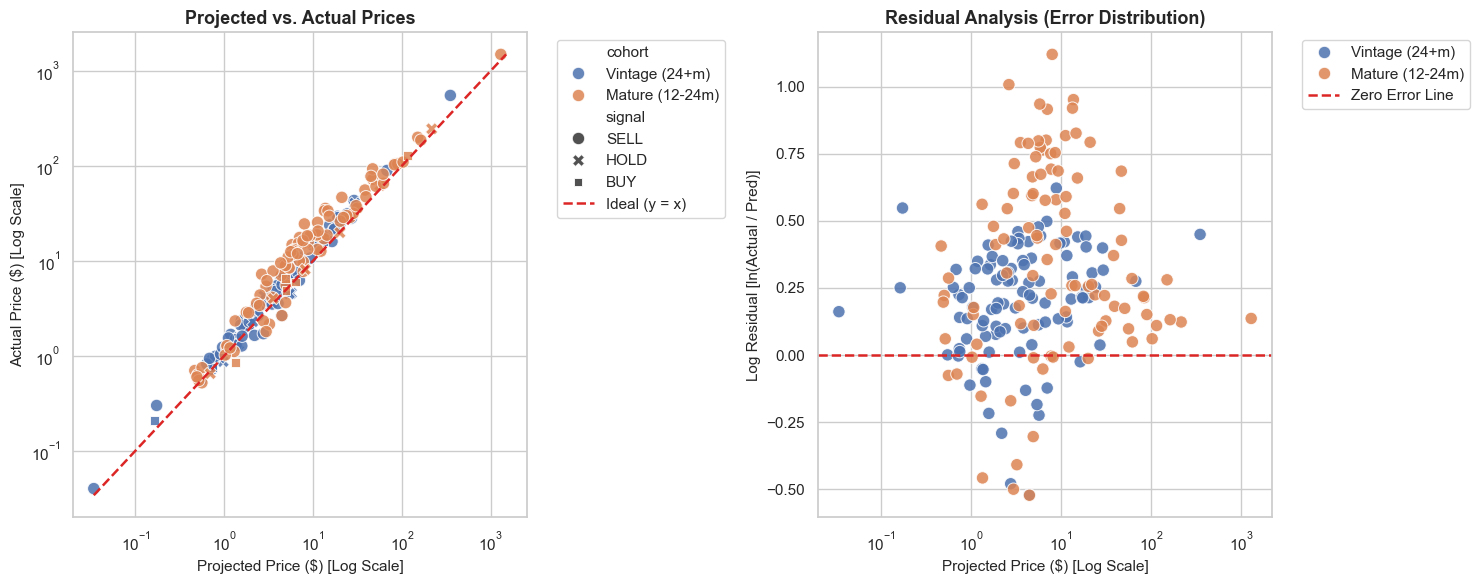

In [65]:
# 1. Filter out cards without a matching ground-truth actual price
eval_df = simulation_results.dropna(
subset=["actual_price_at_t_if_available"]
).copy()

if eval_df.empty:
  print("No actual prices available to plot.")
else:
  y_pred = eval_df["projected_t_price"].values
  y_true = eval_df["actual_price_at_t_if_available"].values

  # Dollar residuals: positive = underpredicted, negative = overpredicted
  eval_df["dollar_residual"] = y_true - y_pred

  # Log residuals (Percentage error scale)
  eval_df["log_residual"] = np.log(y_true / y_pred)

  sns.set_theme(style="whitegrid")
  fig, axes = plt.subplots(1, 2, figsize=(15, 6))

  sns.scatterplot(
      data=eval_df,
      x="projected_t_price",
      y="actual_price_at_t_if_available",
      hue="cohort" if "cohort" in eval_df.columns else None,
      style="signal" if "signal" in eval_df.columns else None,
      alpha=0.85,
      s=80,
      ax=axes[0],
  )

  min_val = min(y_pred.min(), y_true.min())
  max_val = max(y_pred.max(), y_true.max())
  axes[0].plot(
      [min_val, max_val],
      [min_val, max_val],
      color="#dc2626",
      linestyle="--",
      linewidth=1.8,
      label="Ideal (y = x)",
  )

  axes[0].set_xscale("log")
  axes[0].set_yscale("log")
  axes[0].set_xlabel("Projected Price ($) [Log Scale]", fontsize=11)
  axes[0].set_ylabel("Actual Price ($) [Log Scale]", fontsize=11)

  axes[0].set_title(
      "Projected vs. Actual Prices", fontsize=13, fontweight="bold"
  )
  axes[0].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

  res_col = "log_residual"
  y_label = (
      "Log Residual [ln(Actual / Pred)]"
  )

  sns.scatterplot(
      data=eval_df,
      x="projected_t_price",
      y=res_col,
      hue="cohort" if "cohort" in eval_df.columns else None,
      alpha=0.85,
      s=80,
      ax=axes[1],
  )

  # Zero error reference line
  axes[1].axhline(
      0,
      color="#dc2626",
      linestyle="--",
      linewidth=1.8,
      label="Zero Error Line",
  )

  axes[1].set_xscale("log")
  axes[1].set_xlabel("Projected Price ($) [Log Scale]", fontsize=11)

  axes[1].set_ylabel(y_label, fontsize=11)
  axes[1].set_title(
      "Residual Analysis (Error Distribution)", fontsize=13, fontweight="bold"
  )
  axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

  plt.tight_layout()
  plt.show()

In [66]:
from IPython.display import HTML

def display_simulation_table(results_df, card_image_dict):
    df = results_df.copy()
    
    df["image_url"] =  df["set"] + "/" + df["number"].astype(str)
    df["image_url"] = df["image_url"].map(card_image_dict)
    df['Image'] = df['image_url'].apply(
        lambda url: f'<img src="{url}" style="height: 75px; max-width: 75px; object-fit: contain; border-radius: 4px;" />' 
        if pd.notna(url) and str(url).startswith('http') 
        else '<span style="color: #9ca3af;">No Image</span>'
    )
    
    # 2. Format Currency and Return Percentages
    df['Months Simulated'] = df['months_simulated'].apply(lambda x: f"{x} month{'s' if x != 1 else ''}")
    df['Current Price'] = df['start_price'].apply(lambda x: f"${x:,.2f}")
    df['Projected'] = df['projected_t_price'].apply(lambda x: f"${x:,.2f}") 
    df['Actual Price at t'] = df['actual_price_at_t_if_available'].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else '<span style="color: #9ca3af;">N/A</span>')
    df['Return'] = df['cumulative_return_pct'].apply(lambda x: f"{x:+.2f}%")
    
    # 3. Add Color Badges for Signals
    def format_badge(signal):
        badge_styles = {
            'BUY': 'background-color: #16a34a; color: white;',
            'SELL': 'background-color: #dc2626; color: white;',
            'HOLD': 'background-color: #4b5563; color: white;'
        }
        style = badge_styles.get(signal, 'background-color: #9ca3af; color: white;')
        return f'<span style="{style} padding: 4px 10px; border-radius: 12px; font-weight: 600; font-size: 11px; letter-spacing: 0.5px;">{signal}</span>'
    
    df['Signal'] = df['signal'].apply(format_badge)
    df['Actual Signal'] = df['actual_signal_if_available'].apply(lambda x: format_badge(x) if pd.notna(x) else '<span style="color: #9ca3af;">N/A</span>')
    
    # 4. Select and Rename Display Columns
    display_cols = {
        'Image': 'Card Image',
        'card': 'Card Key (Series/Number)',
        'cohort': 'Cohort',
        'Months Simulated': 'Months Simulated',
        'Current Price': 'Current Price',
        'Projected': 'Projected Price',
        'Actual Price at t': 'Actual Price at t',
        'Return': 'Exp. Return (%)',
        'Signal': 'Signal',
        'Actual Signal': 'Actual Signal'
    }
    
    table_df = df[list(display_cols.keys())].rename(columns=display_cols)
    
    # 5. Apply Custom CSS Styling for Notebook Output
    html_content = table_df.to_html(escape=False, index=False)
    
    styled_table = f"""
    <style>
        .card-sim-table {{
            border-collapse: collapse;
            width: 100%;
            font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, Helvetica, Arial, sans-serif;
            font-size: 13px;
        }}
        .card-sim-table th {{
            background-color: #1f2937;
            color: #f9fafb;
            text-align: left;
            padding: 10px 14px;
            font-weight: 600;
        }}
        .card-sim-table td {{
            padding: 8px 14px;
            border-bottom: 1px solid #e5e7eb;
            vertical-align: middle;
        }}
        .card-sim-table tr:hover {{
            background-color: #f3f4f6;
        }}
    </style>
    {html_content.replace('class="dataframe"', 'class="card-sim-table"')}
    """
    
    return HTML(styled_table)

In [67]:
card_image = json.load(open(DATA_DIR / "card_image_urls.json", "r"))

In [68]:
display_simulation_table(sorted_results, card_image)

Card Image,Card Key (Series/Number),Cohort,Months Simulated,Current Price,Projected Price,Actual Price at t,Exp. Return (%),Signal,Actual Signal
No Image,Rowlet,Hype (New),8 months,$5.31,$7.38,N/A,+38.93%,BUY,N/A
No Image,Ampharos,Hype (New),10 months,$7.59,$9.82,N/A,+29.35%,BUY,N/A
No Image,Xerneas,Hype (New),10 months,$8.33,$10.65,N/A,+27.86%,BUY,N/A
,Meowth ex,Hype (New),8 months,$129.56,$152.01,N/A,+17.33%,BUY,N/A
,Porygon-Z,Vintage (24+m),4 months,$11.14,$12.99,$16.01,+16.63%,BUY,BUY
,Mega Starmie ex,Hype (New),8 months,$5.24,$5.99,N/A,+14.40%,BUY,N/A
,Mega Starmie ex,Hype (New),8 months,$41.04,$46.49,N/A,+13.27%,BUY,N/A
,Noibat,Mature (12-24m),4 months,$5.58,$6.29,$5.97,+12.68%,BUY,BUY
No Image,Talonflame,Hype (New),8 months,$1.99,$2.24,N/A,+12.34%,BUY,N/A
No Image,Pikachu ex,Mature (12-24m),4 months,$4.47,$4.95,$4.90,+10.72%,BUY,BUY
